<div style="color:#3c4d5a; border-top: 7px solid #42A5F5; border-bottom: 7px solid #42A5F5; padding: 5px; text-align: center; text-transform: uppercase"><h1>Analisis Exploratorio - Generación Dataset</h1> </div>

### **Nombre:** Diego Bravo
### **Carrera:** Computación

Importar Módulos

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import os
import seaborn as sns

In [30]:
num_dias = 60
productos = [
    {"id": 101, "nombre": "Leche Entera 1L", "cat": "Lácteos", "un": "Caja", "st_ini": 500},
    {"id": 102, "nombre": "Arroz Blanco 1kg", "cat": "Granos", "un": "Bolsa", "st_ini": 1200},
    {"id": 103, "nombre": "Aceite Vegetal 900ml", "cat": "Abarrotes", "un": "Botella", "st_ini": 300},
    {"id": 104, "nombre": "Pasta 500g", "cat": "Abarrotes", "un": "Paquete", "st_ini": 450},
    {"id": 105, "nombre": "Café Molido 250g", "cat": "Bebidas", "un": "Sobre", "st_ini": 200},
    {"id": 106, "nombre": "Detergente Líquido 3L", "cat": "Limpieza", "un": "Bidón", "st_ini": 150},
    {"id": 107, "nombre": "Atún en Conserva 140g", "cat": "Enlatados", "un": "Lata", "st_ini": 800},
    {"id": 108, "nombre": "Huevos (Docena)", "cat": "Fresco", "un": "Cartón", "st_ini": 100},
    {"id": 109, "nombre": "Harina de Trigo 1kg", "cat": "Granos", "un": "Bolsa", "st_ini": 600},
    {"id": 110, "nombre": "Papel Higiénico 4u", "cat": "Higiene", "un": "Pack", "st_ini": 400},
]

sales_data = []
inventory_state = {p['id']: p['st_ini'] for p in productos}
fecha_inicio = datetime(2024, 3, 5)

for i in range(num_dias):
    fecha = fecha_inicio + timedelta(days=i)
    is_weekend = fecha.weekday() >= 5
    for p in productos:
        venta = int(np.random.poisson(lam=10 * (1.5 if is_weekend else 1.0)))
        stock_en_momento = inventory_state[p['id']]
        sales_data.append([p['id'], p['nombre'], fecha.strftime('%Y-%m-%d'), venta, stock_en_momento])
        inventory_state[p['id']] = max(0, inventory_state[p['id']] - venta + 5) # Reposición básica

pd.DataFrame(sales_data, columns=['product_id', 'nombre', 'fecha_venta', 'cantidad_vendida', 'stock_en_momento']).to_csv('data/sales_history.csv', index=False)
pd.DataFrame([[p['id'], p['nombre'], p['cat'], p['un'], inventory_state[p['id']], '2025-12-31'] for p in productos], 
             columns=['product_id', 'nombre', 'categoria', 'unidad', 'stock_actual', 'fecha_expiracion']).to_csv('data/inventory.csv', index=False)

Carga Dataset 

In [31]:
df = pd.read_csv('data/sales_history.csv')

df['fecha_venta'] = pd.to_datetime(df['fecha_venta'])

df.head()

,product_id,nombre,fecha_venta,cantidad_vendida,stock_en_momento
0,101,Leche Entera 1L,2024-03-05,9,500
1,102,Arroz Blanco 1kg,2024-03-05,9,1200
2,103,Aceite Vegetal 900ml,2024-03-05,16,300
3,104,Pasta 500g,2024-03-05,5,450
4,105,Café Molido 250g,2024-03-05,12,200


In [32]:
df.describe()

,product_id,fecha_venta,cantidad_vendida,stock_en_momento
count,600.000000,600,600.000000,600.000000
mean,105.500000,2024-04-03 12:00:00,11.341667,306.598333
min,101.000000,2024-03-05 00:00:00,3.000000,0.000000
25%,103.000000,2024-03-19 18:00:00,9.000000,36.000000
50%,105.500000,2024-04-03 12:00:00,11.000000,226.500000
75%,108.000000,2024-04-18 06:00:00,14.000000,458.000000
max,110.000000,2024-05-03 00:00:00,25.000000,1200.000000
std,2.874678,NaN,3.992681,313.103828


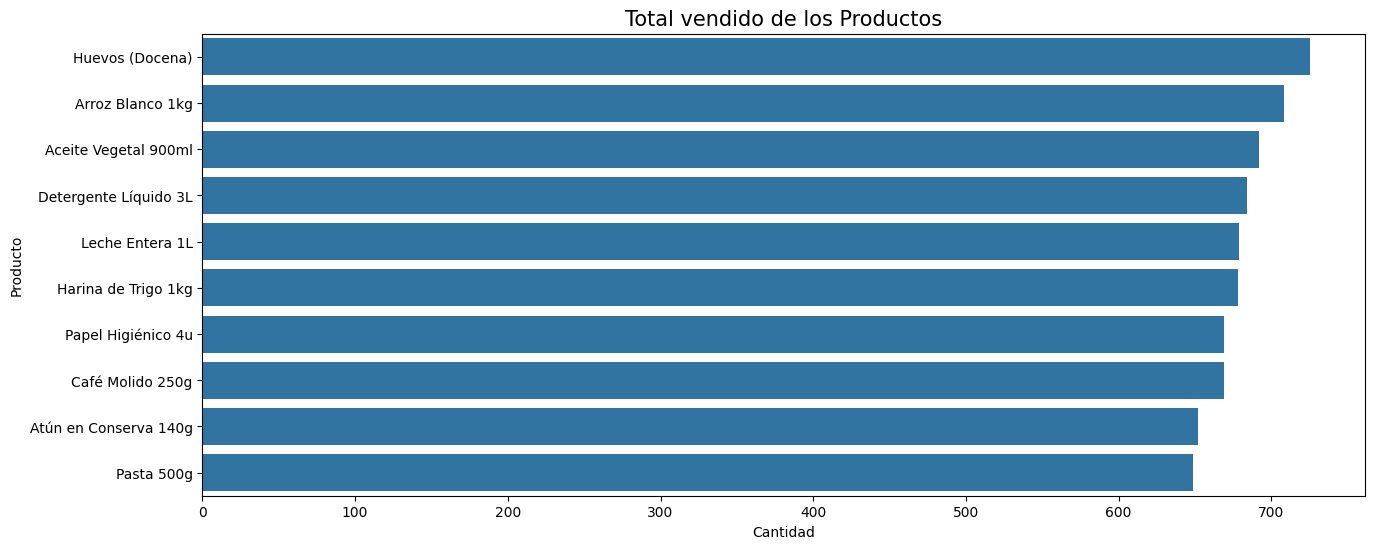

In [33]:
ventas  = df.groupby('nombre')['cantidad_vendida'].sum().sort_values(ascending=False)

plt.figure(figsize=(15,6))
sns.barplot(x=ventas.values, y=ventas.index)
plt.title('Total vendido de los Productos', fontsize=15)
plt.xlabel('Cantidad')
plt.ylabel('Producto')
plt.show()

C:\Users\Usuario\AppData\Local\Temp\ipykernel_15880\2682711922.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=promdia, x='dia_nombre', y='cantidad_vendida', palette='Blues_d')


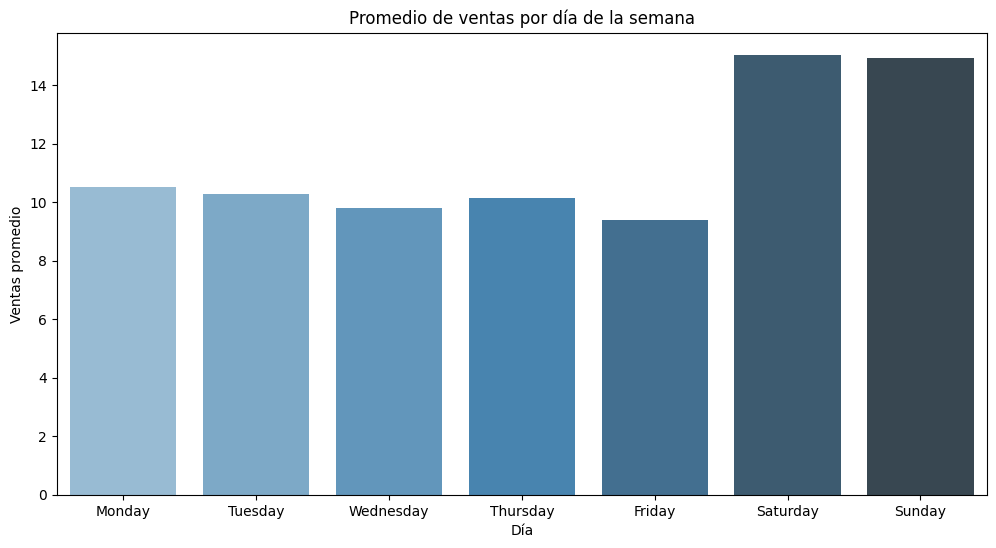

In [34]:
df['dia_nombre'] = df['fecha_venta'].dt.day_name()
df['dia_num'] = df['fecha_venta'].dt.weekday 

promdia = df.groupby(['dia_num', 'dia_nombre'])['cantidad_vendida'].mean().reset_index()
promdia = promdia.sort_values('dia_num')

plt.figure(figsize = (12,6))
sns.barplot(data=promdia, x='dia_nombre', y='cantidad_vendida', palette='Blues_d')
plt.title('Promedio de ventas por día de la semana')
plt.xlabel('Día')
plt.ylabel('Ventas promedio')
plt.show()

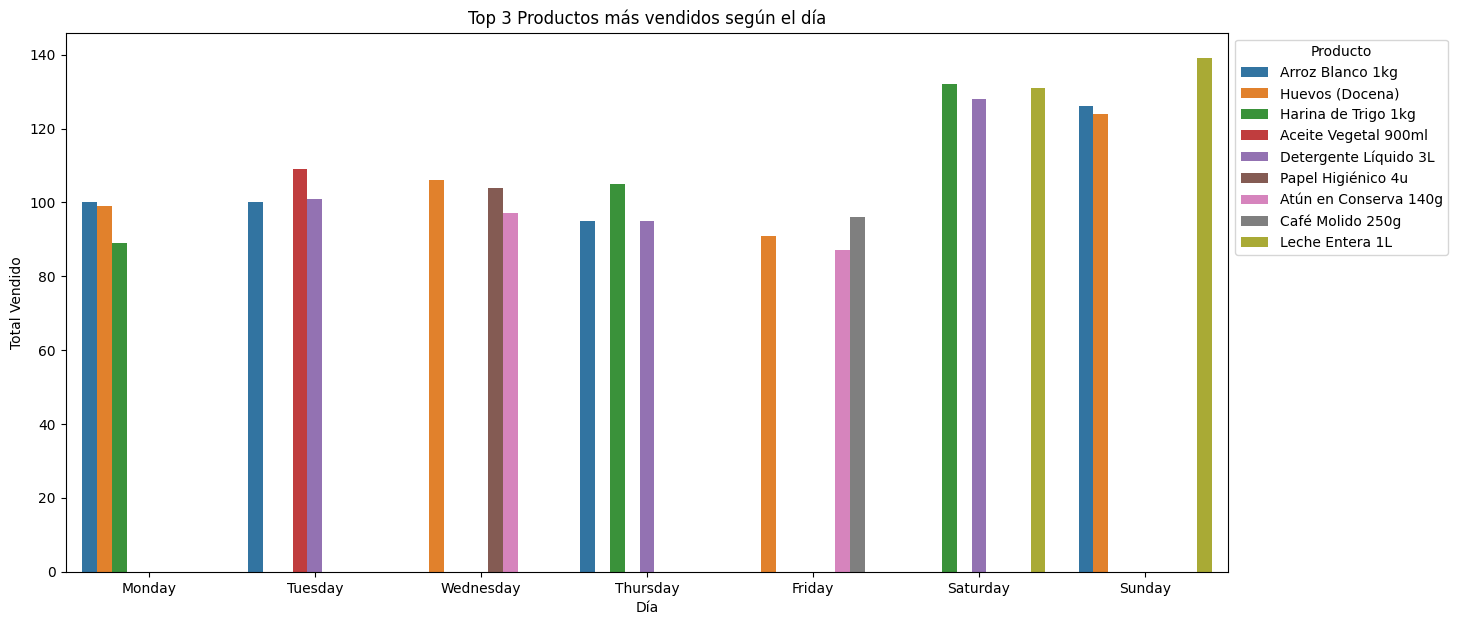

In [35]:
ventas_prod = df.groupby(['dia_nombre', 'dia_num', 'nombre'])['cantidad_vendida'].sum().reset_index()

top_por_dia = ventas_prod.sort_values(['dia_num', 'cantidad_vendida'], ascending=[True, False]).groupby('dia_nombre').head(3)

plt.figure(figsize = (15,7))
sns.barplot(data=top_por_dia, x='dia_nombre', y='cantidad_vendida', hue='nombre')
plt.title('Top 3 Productos más vendidos según el día')
plt.xlabel('Día')
plt.ylabel('Total Vendido')
plt.legend(title='Producto', bbox_to_anchor=(1, 1))
plt.show()

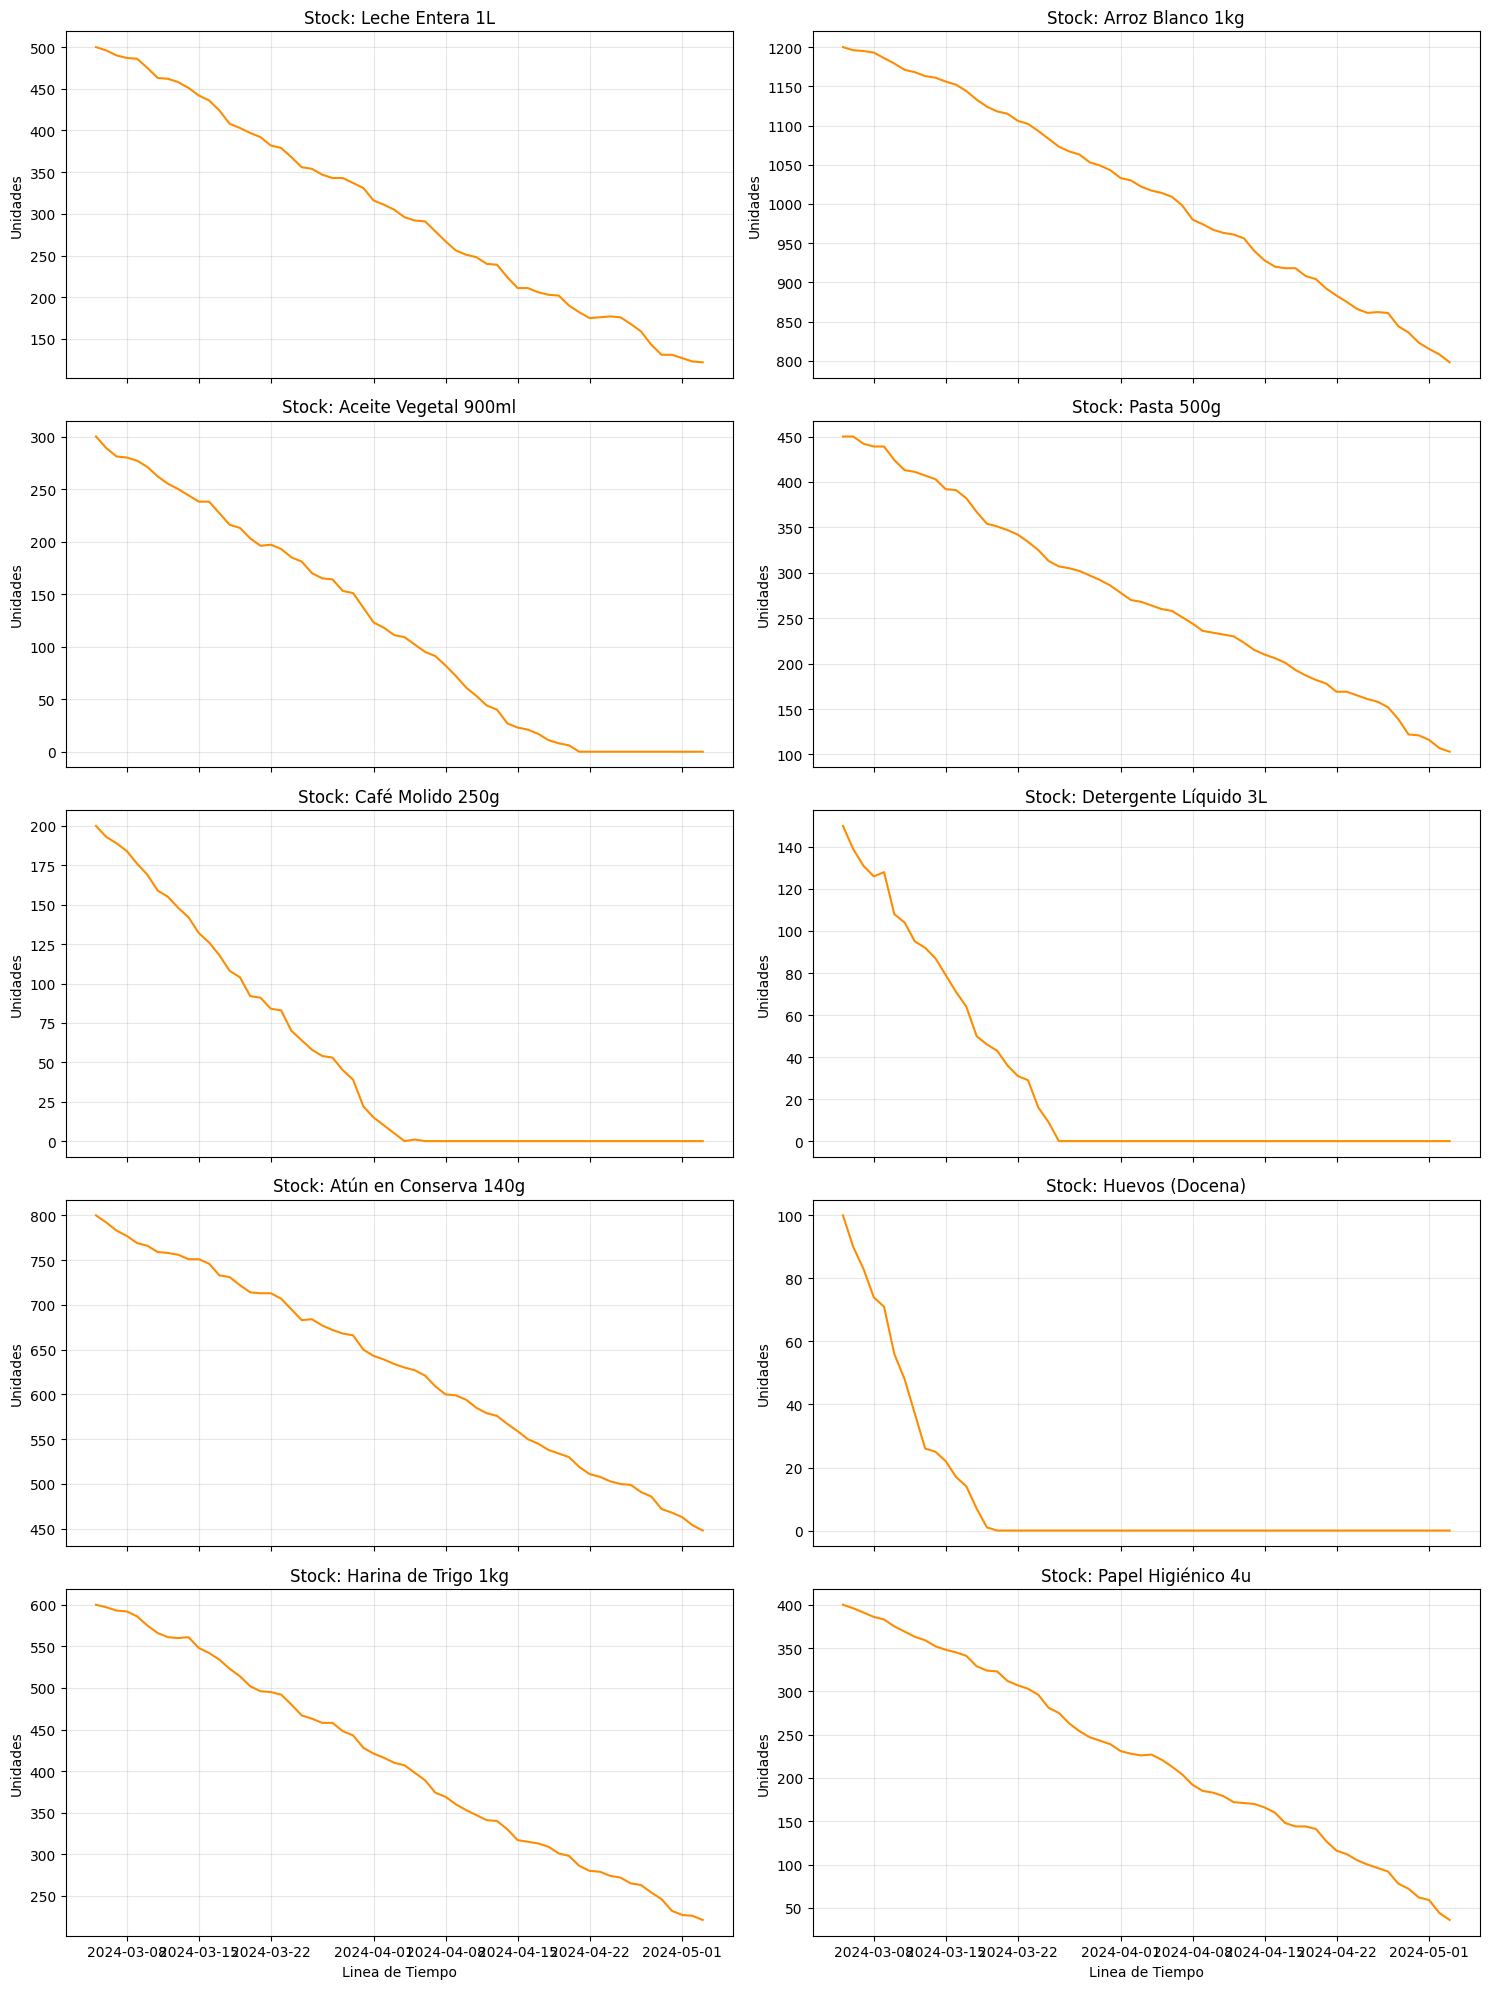

In [36]:
productos =  df['nombre'].unique()
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(15,20), sharex=True)
axes = axes.flatten()

for i, producto in enumerate(productos):
    datos_p = df[df['nombre'] == producto]
    axes[i].plot(datos_p['fecha_venta'], datos_p['stock_en_momento'], color='darkorange')
    axes[i].set_title(f'Stock: {producto}')
    axes[i].grid(True, alpha=0.3)
    if i >= 8:
        axes[i].set_xlabel('Linea de Tiempo')
    axes[i].set_ylabel('Unidades')

plt.tight_layout()
plt.show()

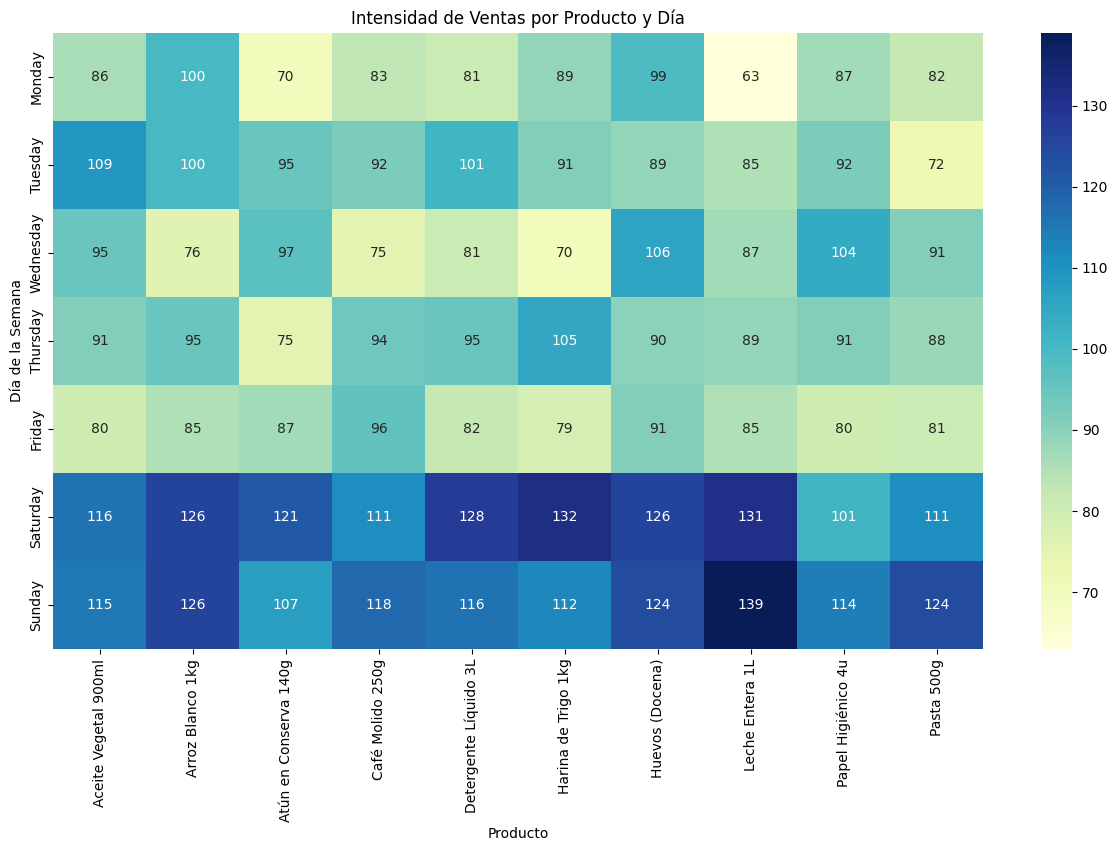

In [41]:
dias_ordenados = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

pivot = df.pivot_table(index='dia_nombre', columns='nombre', values='cantidad_vendida', aggfunc='sum').reindex(dias_ordenados)

plt.figure(figsize = (15,8))
sns.heatmap(pivot, cmap='YlGnBu', annot=True, fmt=".0f")
plt.title('Intensidad de Ventas por Producto y Día')
plt.xlabel('Producto')
plt.ylabel('Día de la Semana')
plt.show()